In [ ]:
import matplotlib.pyplot as plt
import numpy as np

from ugdatalab import (
    GaiaData,
    fourier_fit,
    cross_validate,
    lomb_scargle,
    RRLYRAE_PERIOD_MIN,
    RRLYRAE_PERIOD_MAX,
)

from plotters import (
    plot_raw_phase_folded_lightcurve,
    plot_lomb_scargle_periodogram,
    plot_vari_rrlyrae_period_comparison,
    plot_fourier_harmonic_fits,
    plot_fourier_cross_validation,
    plot_fourier_cv_residual_histograms,
    plot_fourier_cv_phase_comparison,
    plot_fourier_extrapolation,
    plot_mean_g_catalog_comparison,
    plot_rrlyrae_shape_comparison,
)

In [2]:
query = """
SELECT TOP 100 *
FROM gaiadr3.vari_rrlyrae
WHERE pf IS NOT NULL
  AND num_clean_epochs_g > 40
ORDER BY num_clean_epochs_g DESC
"""


In [3]:
rrlyrae = GaiaData(query, include_lightcurve=True)

rrlyrae.data[:10]


Epoch photometry:   0%|          | 0/100 [00:00<?, ?it/s]

solution_id,source_id,pf,pf_error,p1_o,p1_o_error,epoch_g,epoch_g_error,epoch_bp,epoch_bp_error,epoch_rp,epoch_rp_error,epoch_rv,epoch_rv_error,int_average_g,int_average_g_error,int_average_bp,int_average_bp_error,int_average_rp,int_average_rp_error,average_rv,average_rv_error,peak_to_peak_g,peak_to_peak_g_error,peak_to_peak_bp,peak_to_peak_bp_error,peak_to_peak_rp,peak_to_peak_rp_error,peak_to_peak_rv,peak_to_peak_rv_error,metallicity,metallicity_error,r21_g,r21_g_error,r31_g,r31_g_error,phi21_g,phi21_g_error,phi31_g,phi31_g_error,num_clean_epochs_g,num_clean_epochs_bp,num_clean_epochs_rp,num_clean_epochs_rv,zp_mag_g,zp_mag_bp,zp_mag_rp,num_harmonics_for_p1_g,num_harmonics_for_p1_bp,num_harmonics_for_p1_rp,num_harmonics_for_p1_rv,reference_time_g,reference_time_bp,reference_time_rp,reference_time_rv,fund_freq1,fund_freq1_error,fund_freq2,fund_freq2_error,fund_freq1_harmonic_ampl_g,fund_freq1_harmonic_ampl_g_error,fund_freq1_harmonic_phase_g,fund_freq1_harmonic_phase_g_error,fund_freq1_harmonic_ampl_bp,fund_freq1_harmonic_ampl_bp_error,fund_freq1_harmonic_phase_bp,fund_freq1_harmonic_phase_bp_error,fund_freq1_harmonic_ampl_rp,fund_freq1_harmonic_ampl_rp_error,fund_freq1_harmonic_phase_rp,fund_freq1_harmonic_phase_rp_error,fund_freq1_harmonic_ampl_rv,fund_freq1_harmonic_ampl_rv_error,fund_freq1_harmonic_phase_rv,fund_freq1_harmonic_phase_rv_error,best_classification,g_absorption,g_absorption_error,rrlyrae_representative_period,rrlyrae_representative_period_error
,,,,,,d,d,d,d,d,d,d,d,,mag,mag,mag,mag,mag,km / s,km / s,mag,mag,mag,mag,mag,mag,km / s,km / s,dex,dex,,,,,rad,rad,rad,rad,,,,,mag,mag,mag,,,,,d,d,d,d,1 / d,1 / d,1 / d,1 / d,mag,mag,rad,rad,mag,mag,rad,rad,mag,mag,rad,rad,km / s,km / s,rad,rad,,mag,mag,,
int64,int64,float64,float64,float64,float64,float64,float32,float64,float32,float64,float32,float64,float32,float64,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float64,float64,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,int64,int16,int16,int16,float32,float32,float32,int16,int16,int16,int16,float64,float64,float64,float64,float64,float32,float64,float32,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,str4,float32,float32,float64,float64
375316653866487565,5284173207165634048,0.6754204135600004,1.145270016422728e-05,nan,nan,1664.7147255940913,1.6196564e-05,1664.725090176758,4.3462893e-05,1664.7448980260845,5.088851e-05,--,--,19.021461486816406,0.0015568832,19.218428,0.0108482,18.57285,0.007794851,--,--,0.23490465,0.005222299,0.25476402,0.03279039,0.19802193,0.020892723,--,--,-0.9399567,0.39976972,0.3227774,0.021646043,0.1224213,0.021695046,4.2703824,0.08953599,2.5574005,0.23331897,257,246,242,--,19.02329,19.22096,18.573446,3,2,2,--,1666.4768974530693,1666.4772118301444,1666.4773006462092,--,1.4805593374491128,2.5104959e-05,--,--,[0.10287211835384369 0.03320479393005371 0.012593737803399563 -- -- -- --\n -- -- -- -- -- -- -- -- --],[0.002026671776548028 0.002223402028903365 0.002232055412605405 -- -- --\n -- -- -- -- -- -- -- -- -- --],[0.21112152934074402 4.692625045776367 3.190765142440796 0.0 0.0 0.0 0.0\n 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0],[0.027860915288329124 0.06460897624492645 0.2089683562517166 -- -- -- --\n -- -- -- -- -- -- -- -- --],[0.11212261021137238 0.046277161687612534 -- -- -- -- -- -- -- -- -- -- --\n -- -- --],[0.018480001017451286 0.02448887564241886 -- -- -- -- -- -- -- -- -- -- --\n -- -- --],[0.45994314551353455 4.471524715423584 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0\n 0.0 0.0 0.0 0.0 0.0],[0.16694127023220062 0.6190136075019836 -- -- -- -- -- -- -- -- -- -- --\n -- -- --],[0.06839297711849213 0.04667317494750023 -- -- -- -- -- -- -- -- -- -- --\n -- -- --],[0.011212748475372791 0.009829183109104633 -- -- -- -- -- -- -- -- -- --\n -- -- -- --],[6.272590160369873 4.2616424560546875 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0\n 0.0 0.0 0.0 0.0 0.0],[

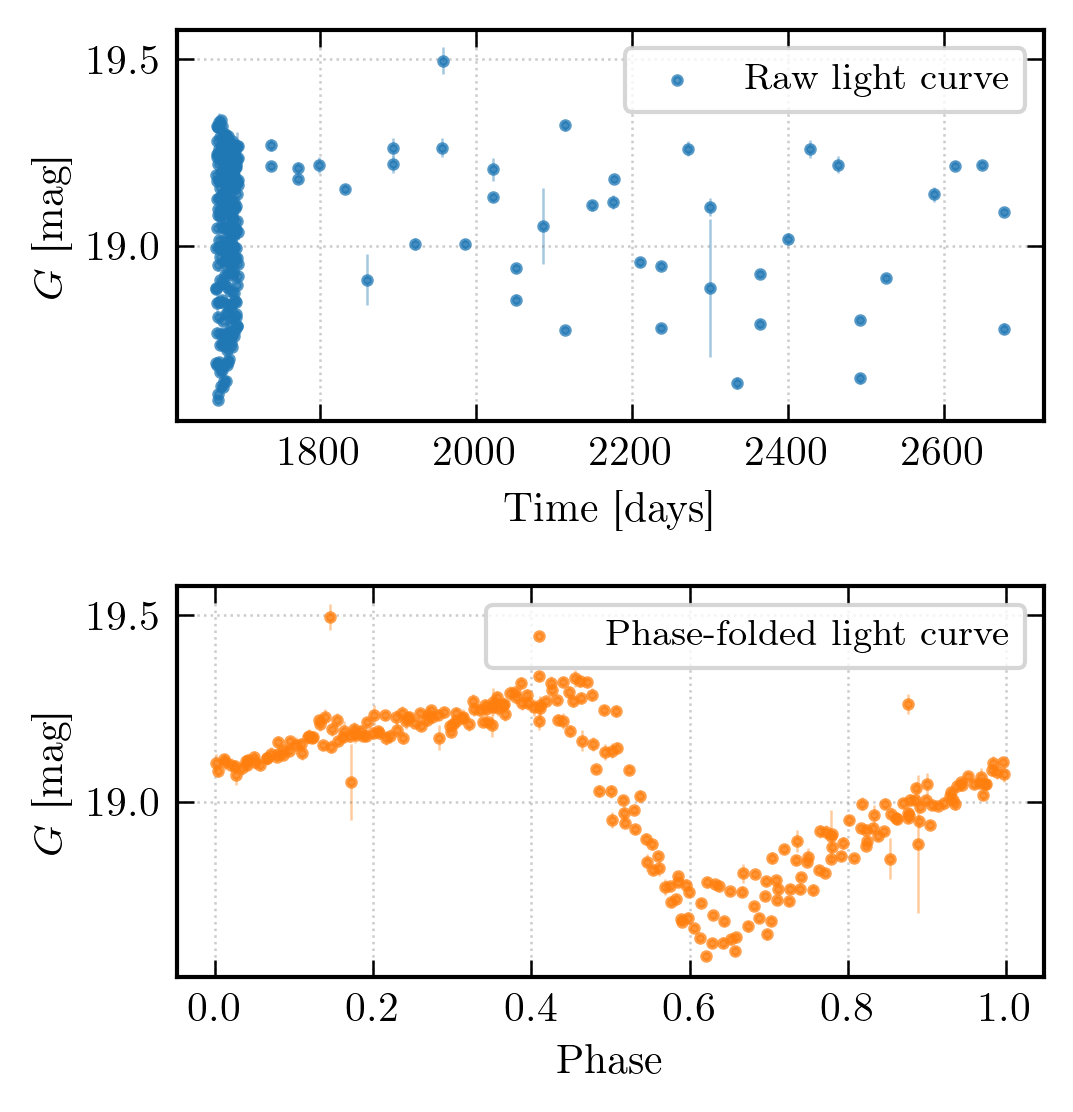

In [4]:
TARGET_ID = 4659759557323962752

axes = plot_raw_phase_folded_lightcurve(rrlyrae, TARGET_ID)
plt.show()

In [ ]:
lightcurve = rrlyrae.lightcurves[rrlyrae.lightcurves["source_id"] == TARGET_ID]

result = lomb_scargle(
    lightcurve["g_transit_time"],
    lightcurve["g_transit_flux"],
    lightcurve["g_transit_flux_error"],
    RRLYRAE_PERIOD_MIN,
    RRLYRAE_PERIOD_MAX,
)

ax = plot_lomb_scargle_periodogram(result)
plt.show()

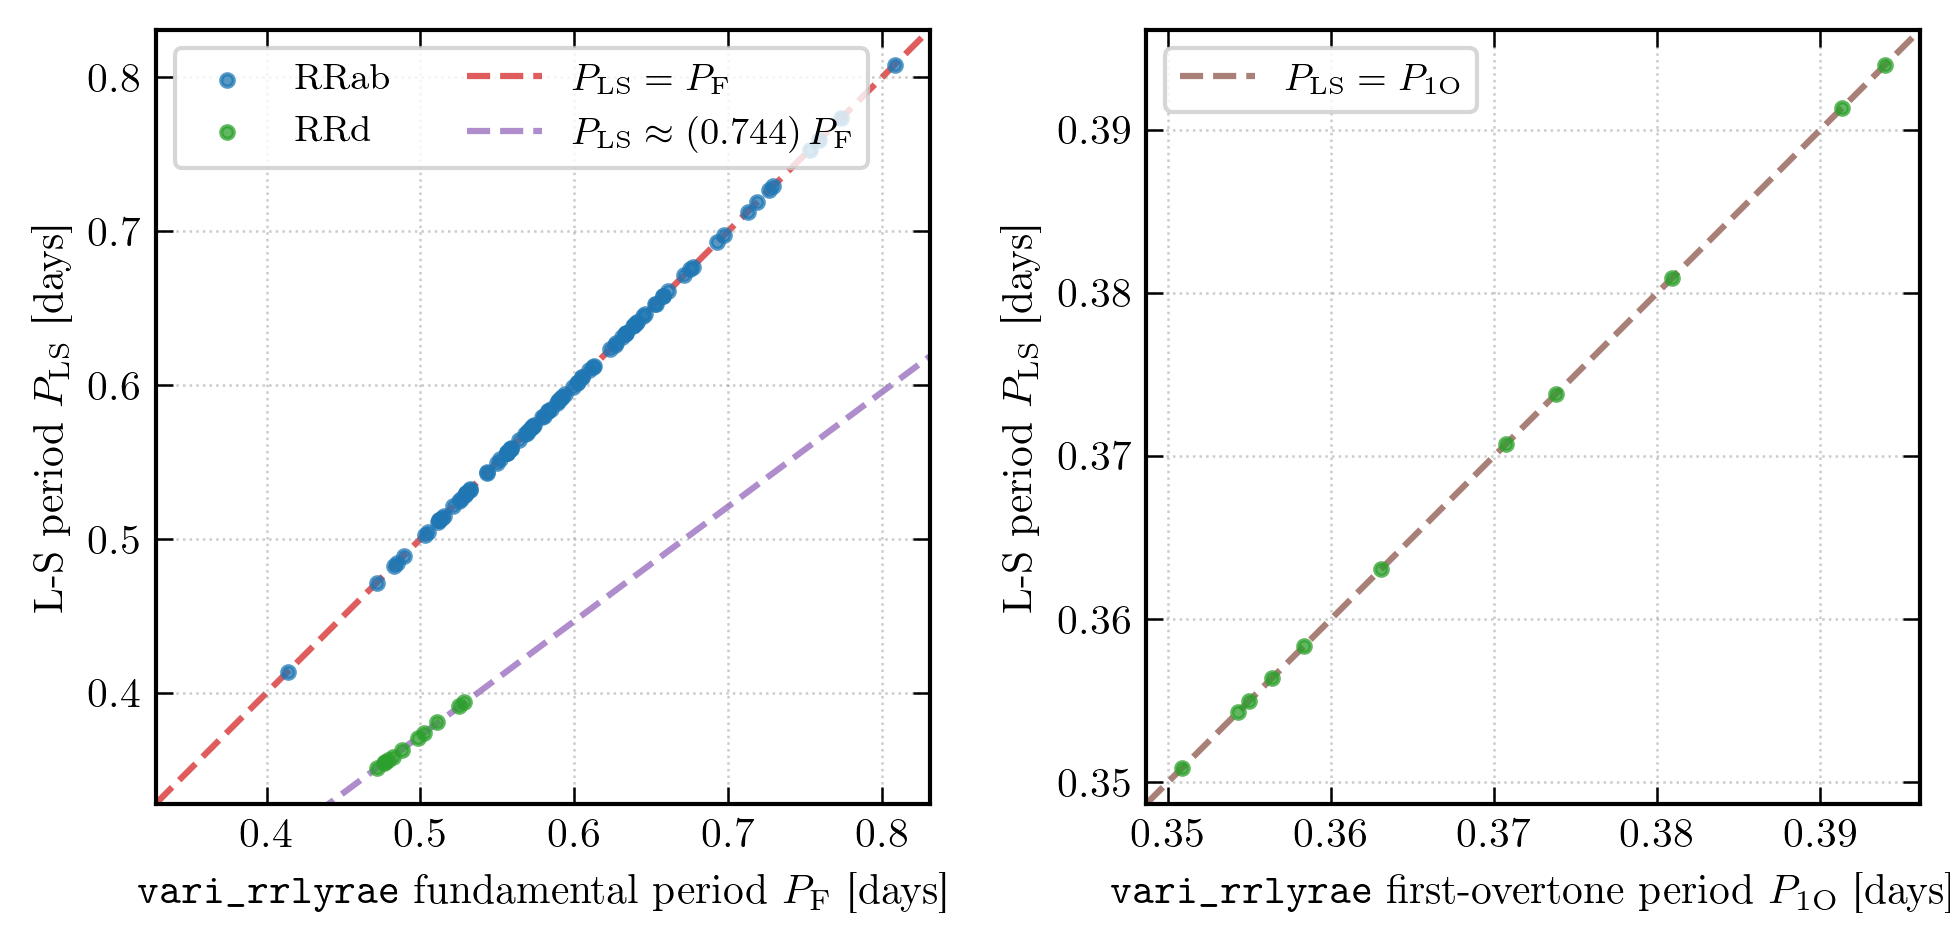

In [6]:
axes = plot_vari_rrlyrae_period_comparison(rrlyrae)
plt.show()

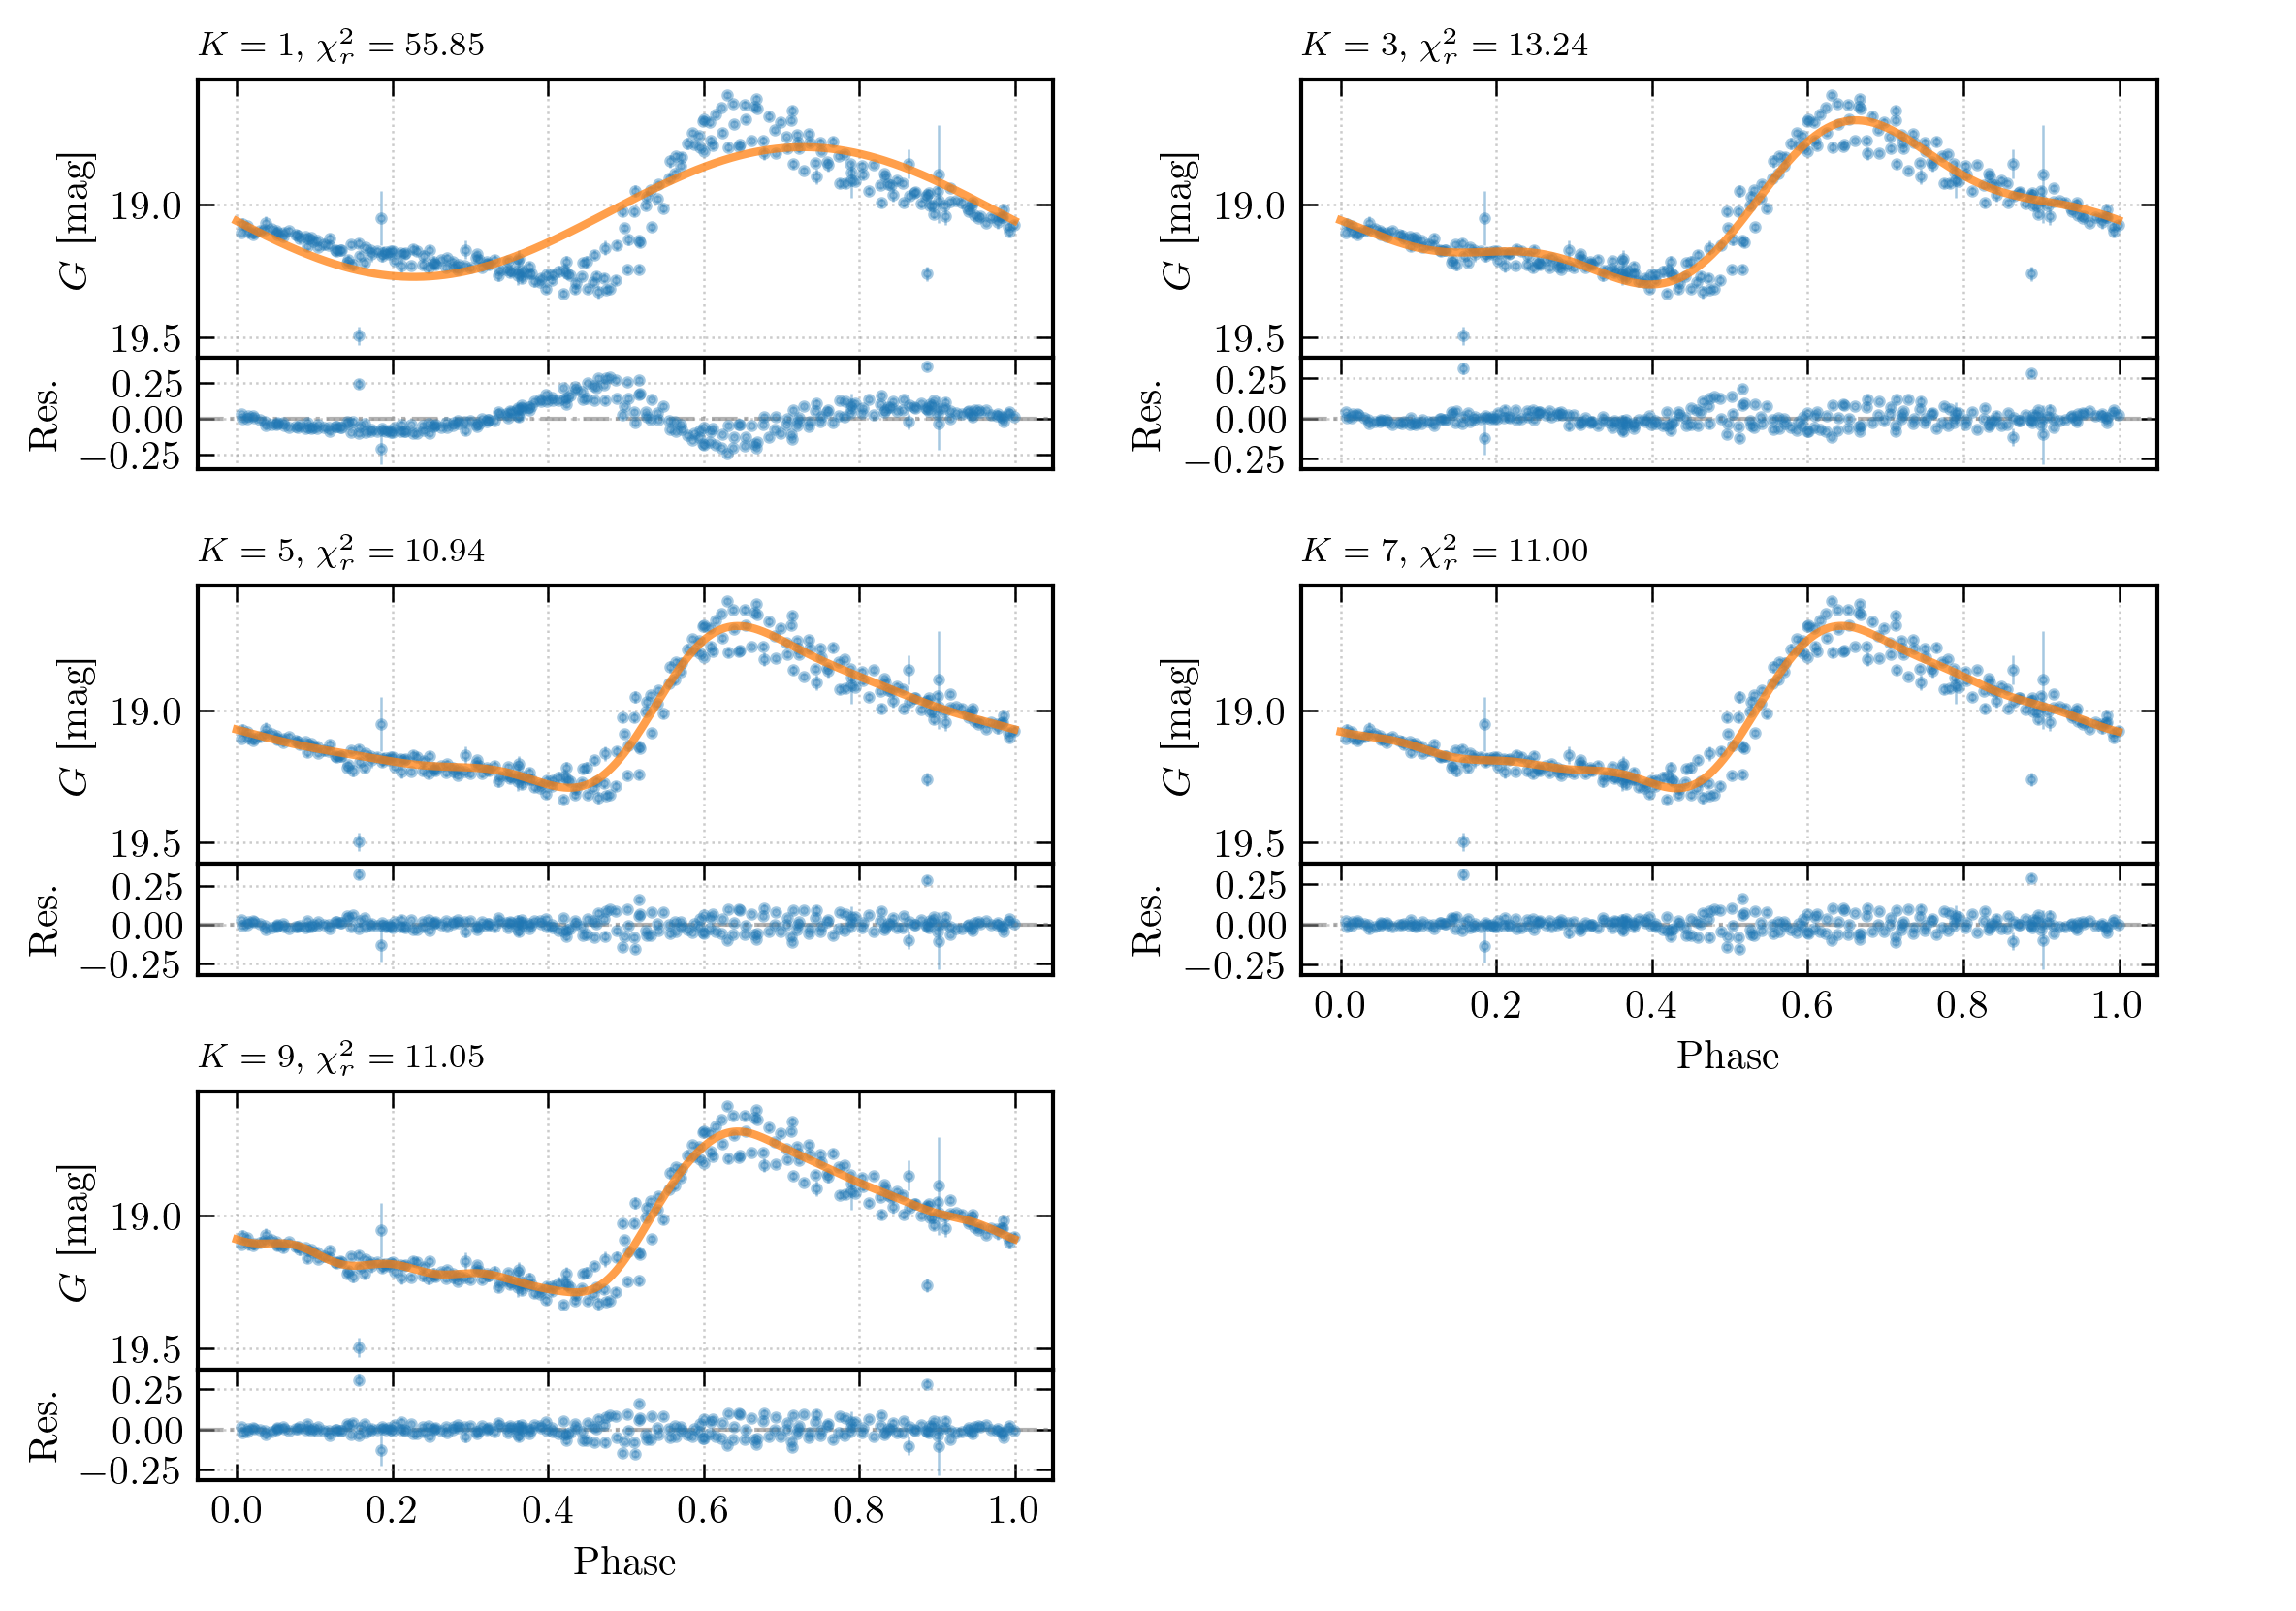

In [7]:
K_values = [1, 3, 5, 7, 9]

axes = plot_fourier_harmonic_fits(rrlyrae, TARGET_ID, K_values)
plt.show()

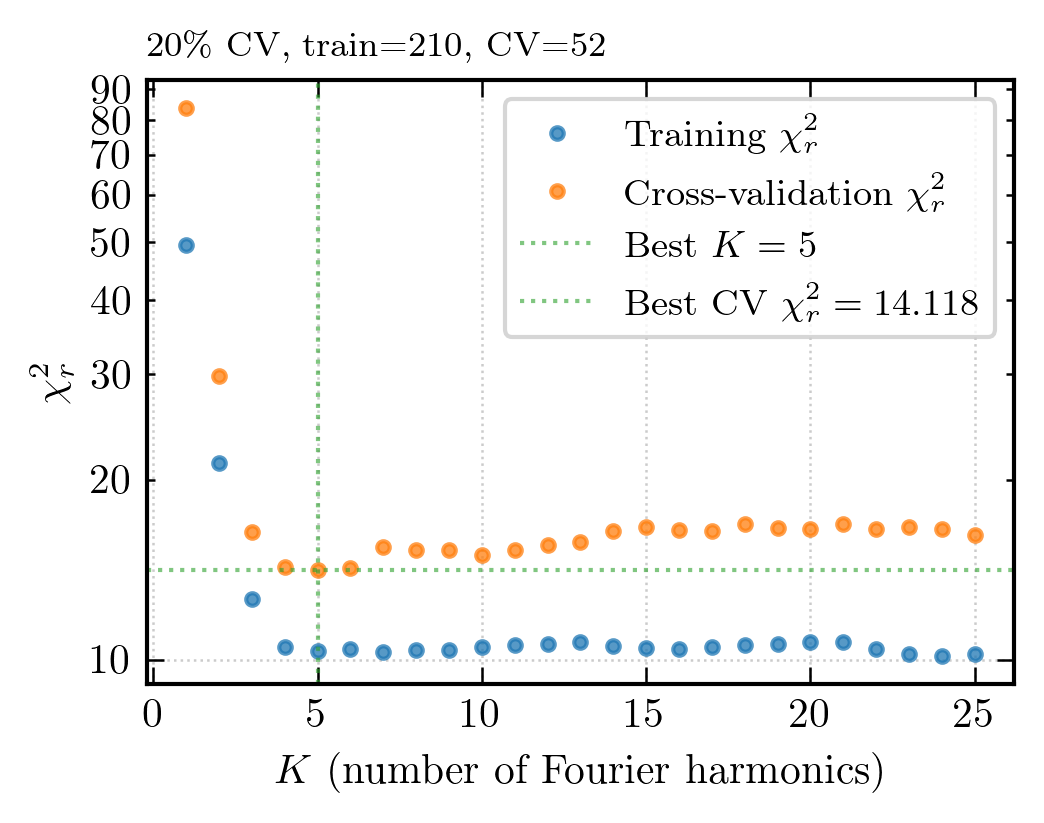

In [8]:
lightcurve = rrlyrae.lightcurves[rrlyrae.lightcurves["source_id"] == TARGET_ID]
period_ls = lightcurve["period_ls"][0]

cv_result = cross_validate(
    lightcurve["g_transit_time"],
    lightcurve["g_transit_mag"],
    lightcurve["g_transit_mag_err"],
    lambda x, y, ye, k: fourier_fit(x, y, ye, period_ls, k),
    np.arange(1, 26),
)
best_K = cv_result.best_param

ax = plot_fourier_cross_validation(cv_result)
plt.show()

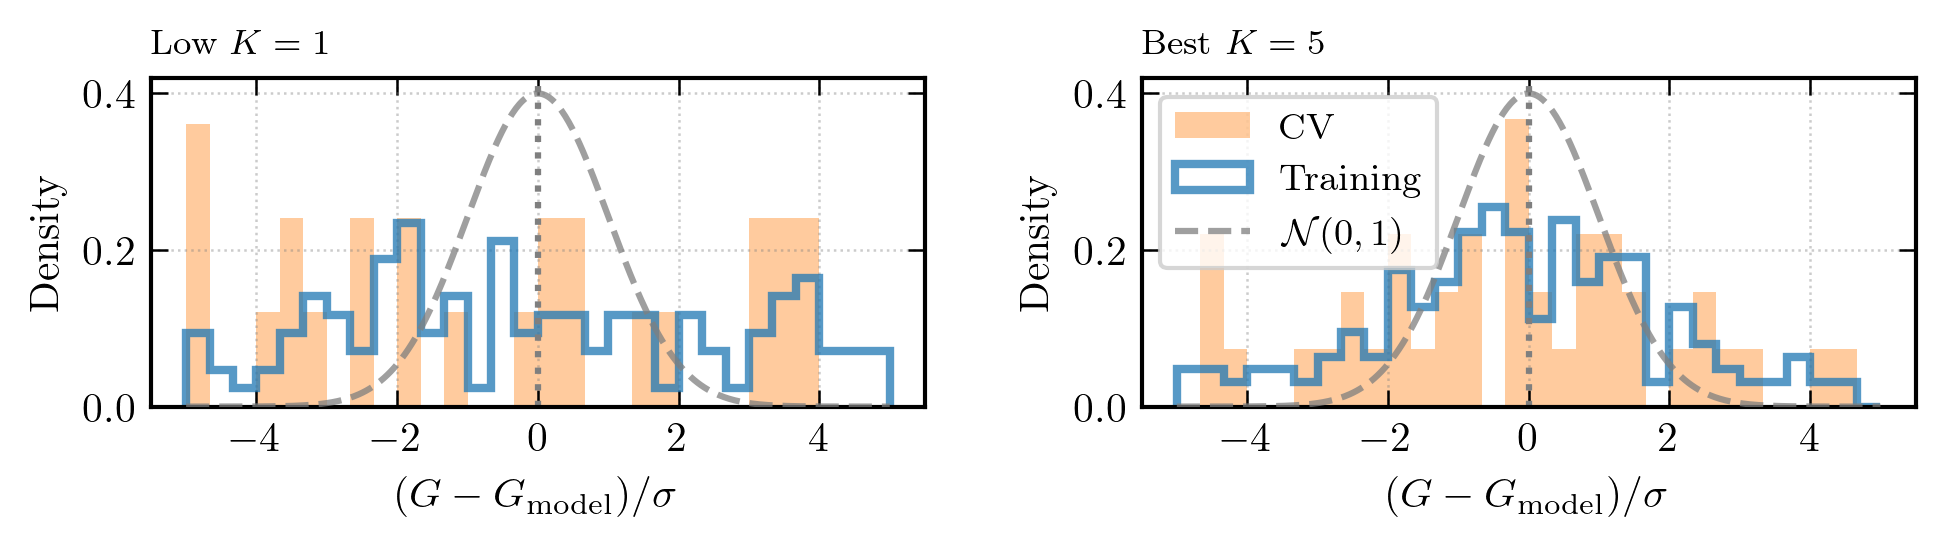

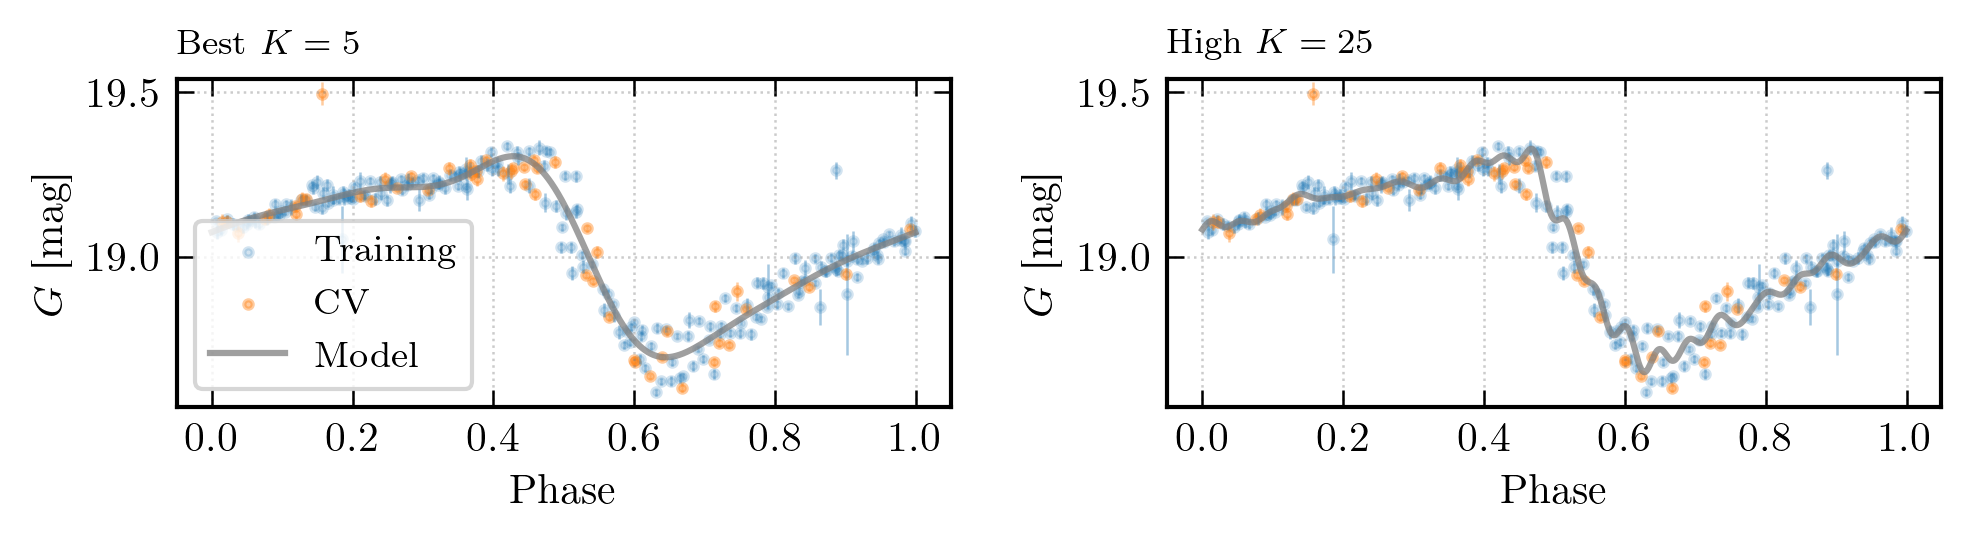

In [9]:
low_K = cv_result.param_values[0]
high_K = cv_result.param_values[-1]

train_idx = cv_result.train_idx
epochs = lightcurve["g_transit_time"]
mags = lightcurve["g_transit_mag"]
mag_errs = lightcurve["g_transit_mag_err"]

low_fit = fourier_fit(epochs[train_idx], mags[train_idx], mag_errs[train_idx], period_ls, low_K)
best_fit = fourier_fit(epochs[train_idx], mags[train_idx], mag_errs[train_idx], period_ls, best_K)
high_fit = fourier_fit(epochs[train_idx], mags[train_idx], mag_errs[train_idx], period_ls, high_K)

axes = plot_fourier_cv_residual_histograms(rrlyrae, TARGET_ID, cv_result, low_fit, best_fit)
plt.show()

axes = plot_fourier_cv_phase_comparison(rrlyrae, TARGET_ID, cv_result, best_fit, high_fit)
plt.show()

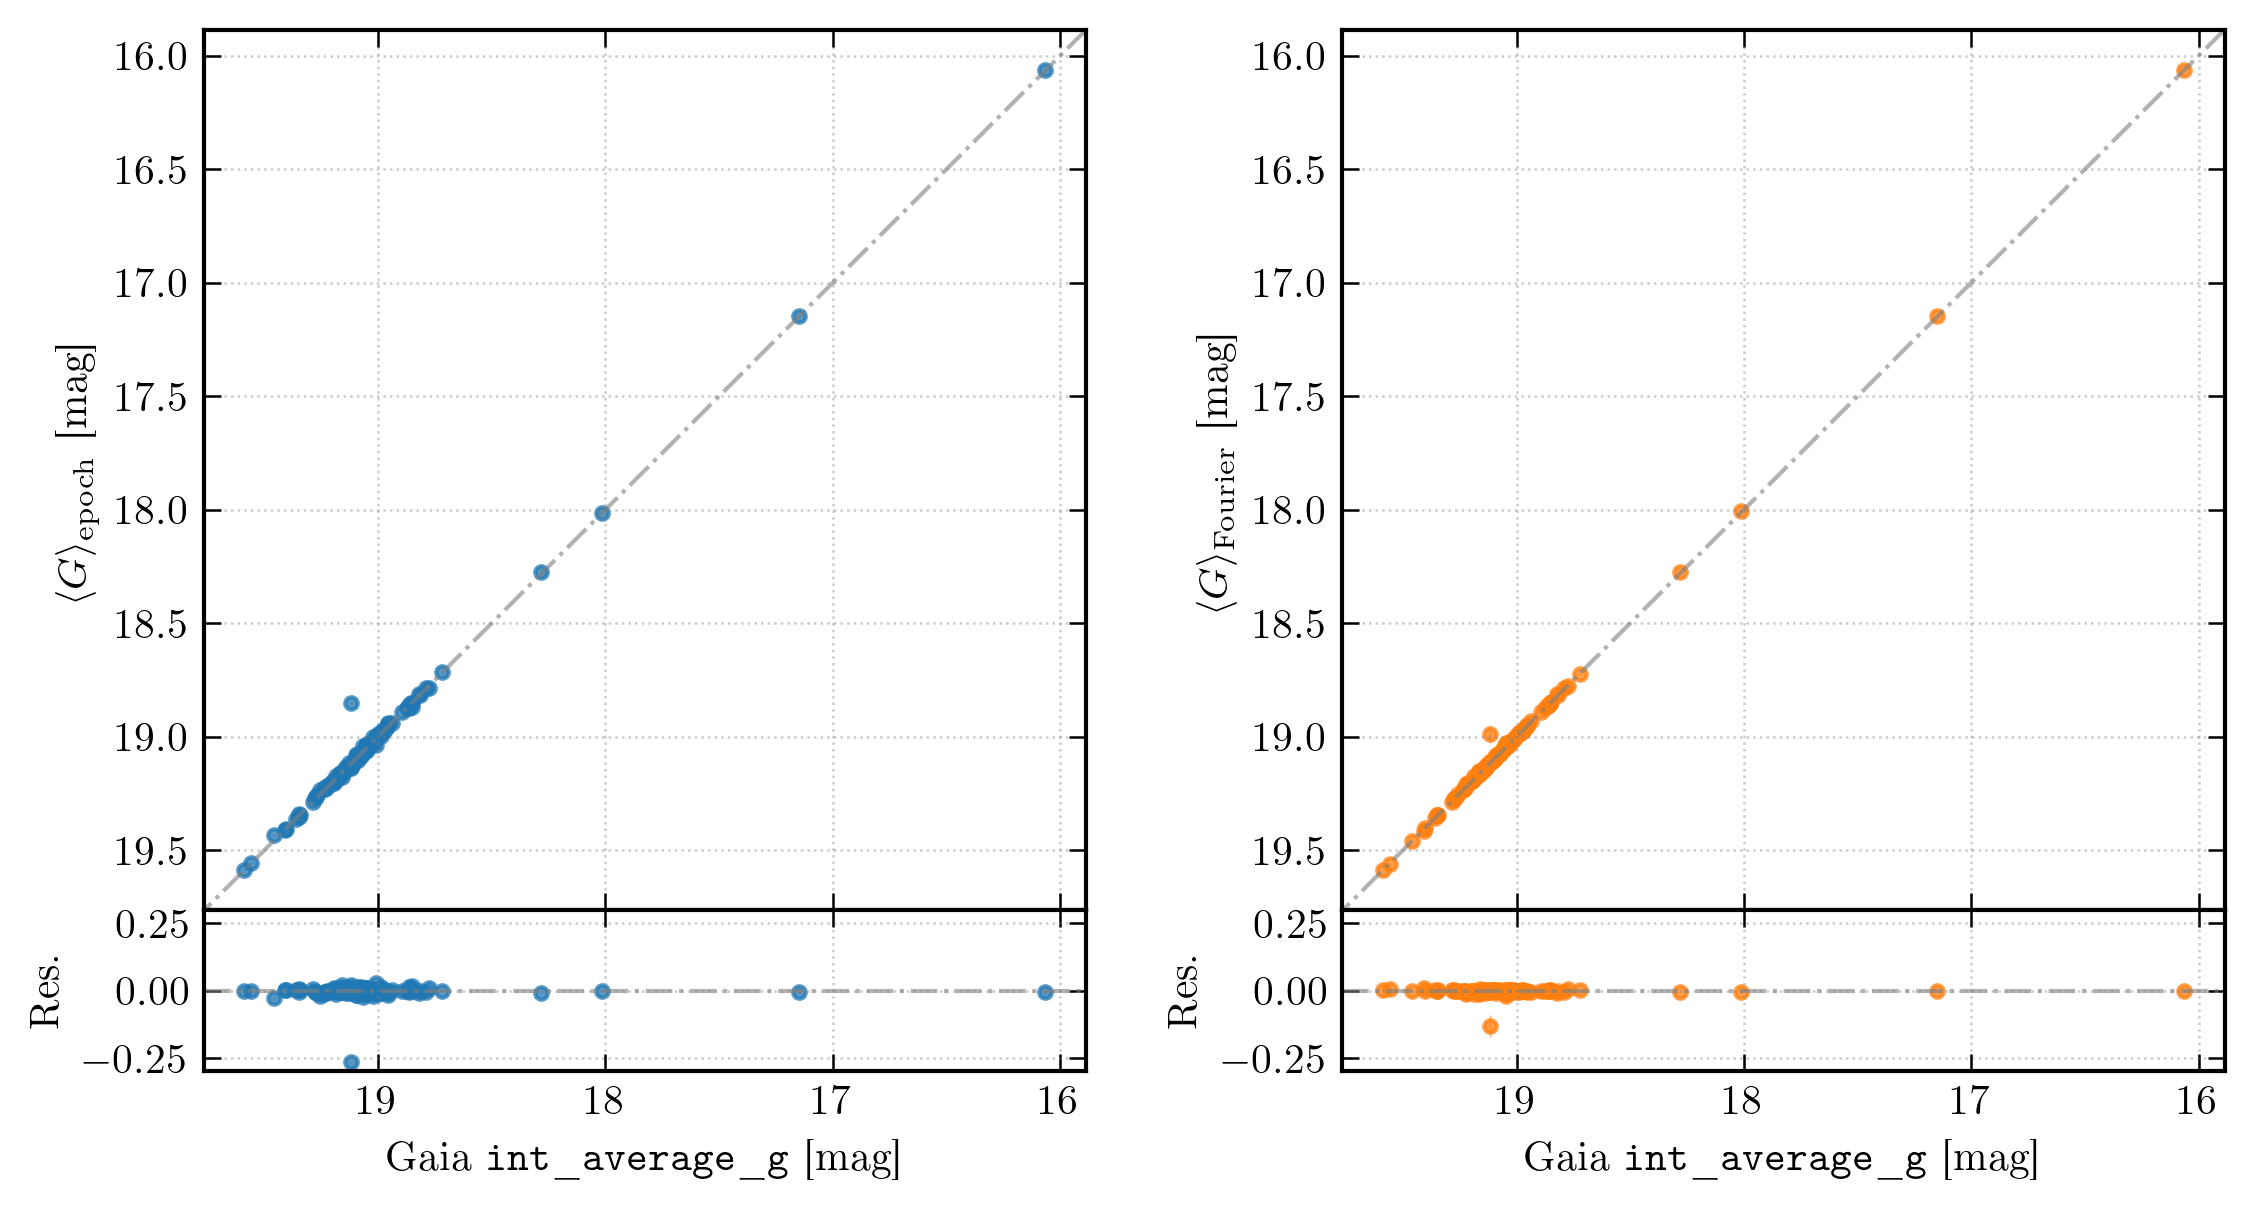

In [10]:
axes = plot_mean_g_catalog_comparison(rrlyrae)
plt.show()

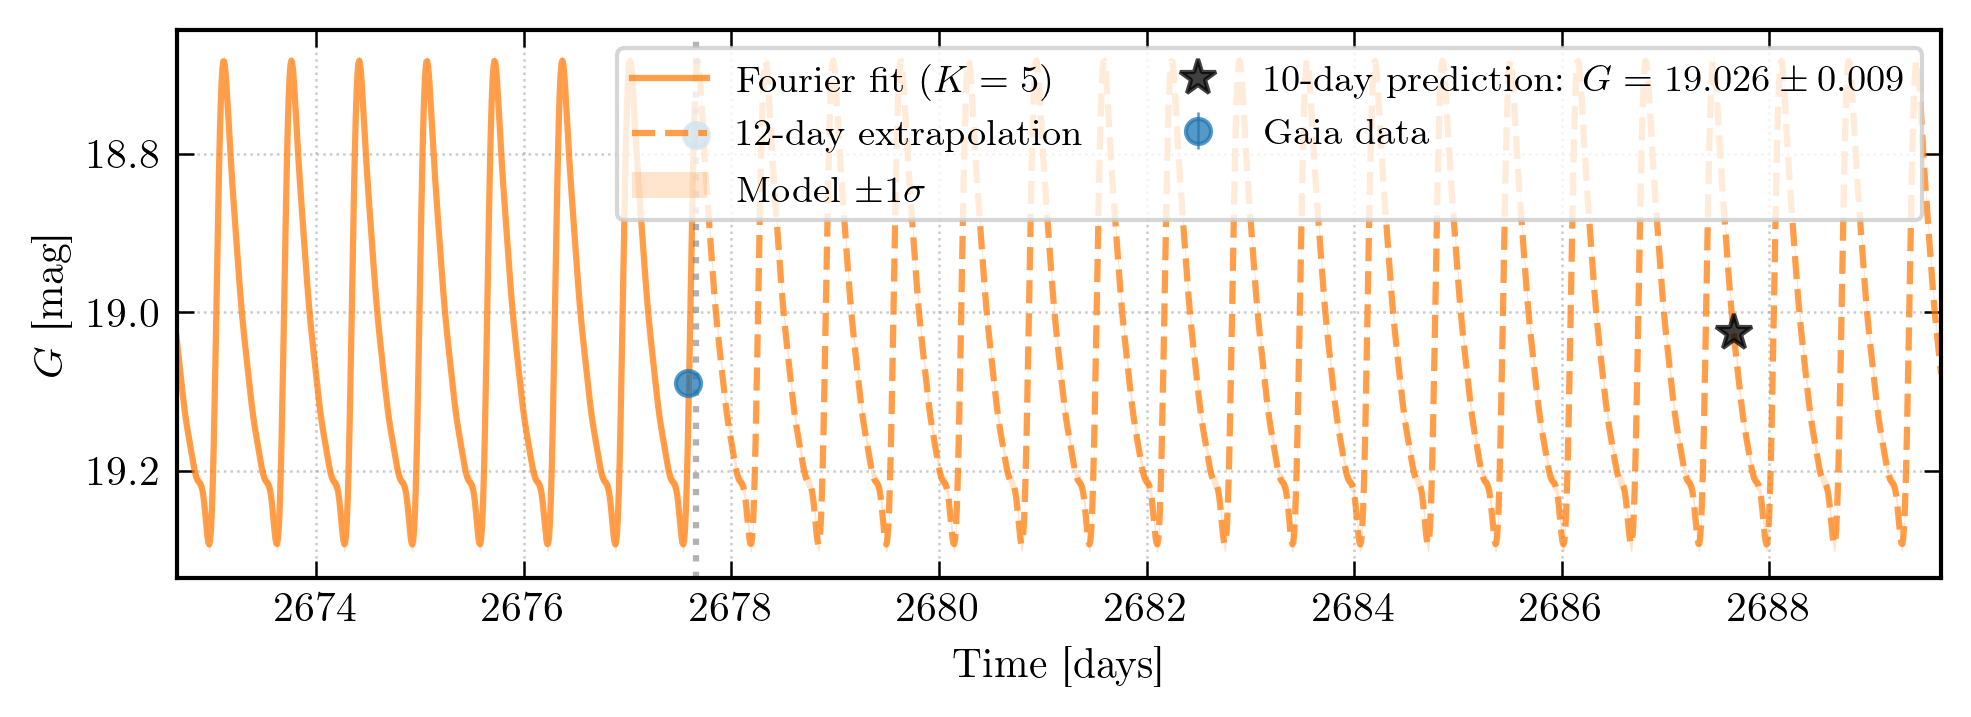

In [11]:
full_fit = fourier_fit(epochs, mags, mag_errs, period_ls, best_K)

ax = plot_fourier_extrapolation(full_fit)
plt.show()

In [12]:
rrc_query = """
SELECT TOP 3 *
FROM gaiadr3.vari_rrlyrae
WHERE p1_o IS NOT NULL
  AND int_average_g  < 15
  AND num_clean_epochs_g > 80
ORDER BY num_clean_epochs_g DESC
"""

rrc = GaiaData(rrc_query, include_lightcurve=True)

Epoch photometry:   0%|          | 0/3 [00:00<?, ?it/s]

In [13]:
rrab_query = """
SELECT TOP 3 *
FROM gaiadr3.vari_rrlyrae
WHERE pf IS NOT NULL
  AND p1_o IS NULL
  AND int_average_g  < 15
  AND num_clean_epochs_g > 80
ORDER BY num_clean_epochs_g DESC
"""

rrab = GaiaData(rrab_query, include_lightcurve=True)

Epoch photometry:   0%|          | 0/3 [00:00<?, ?it/s]

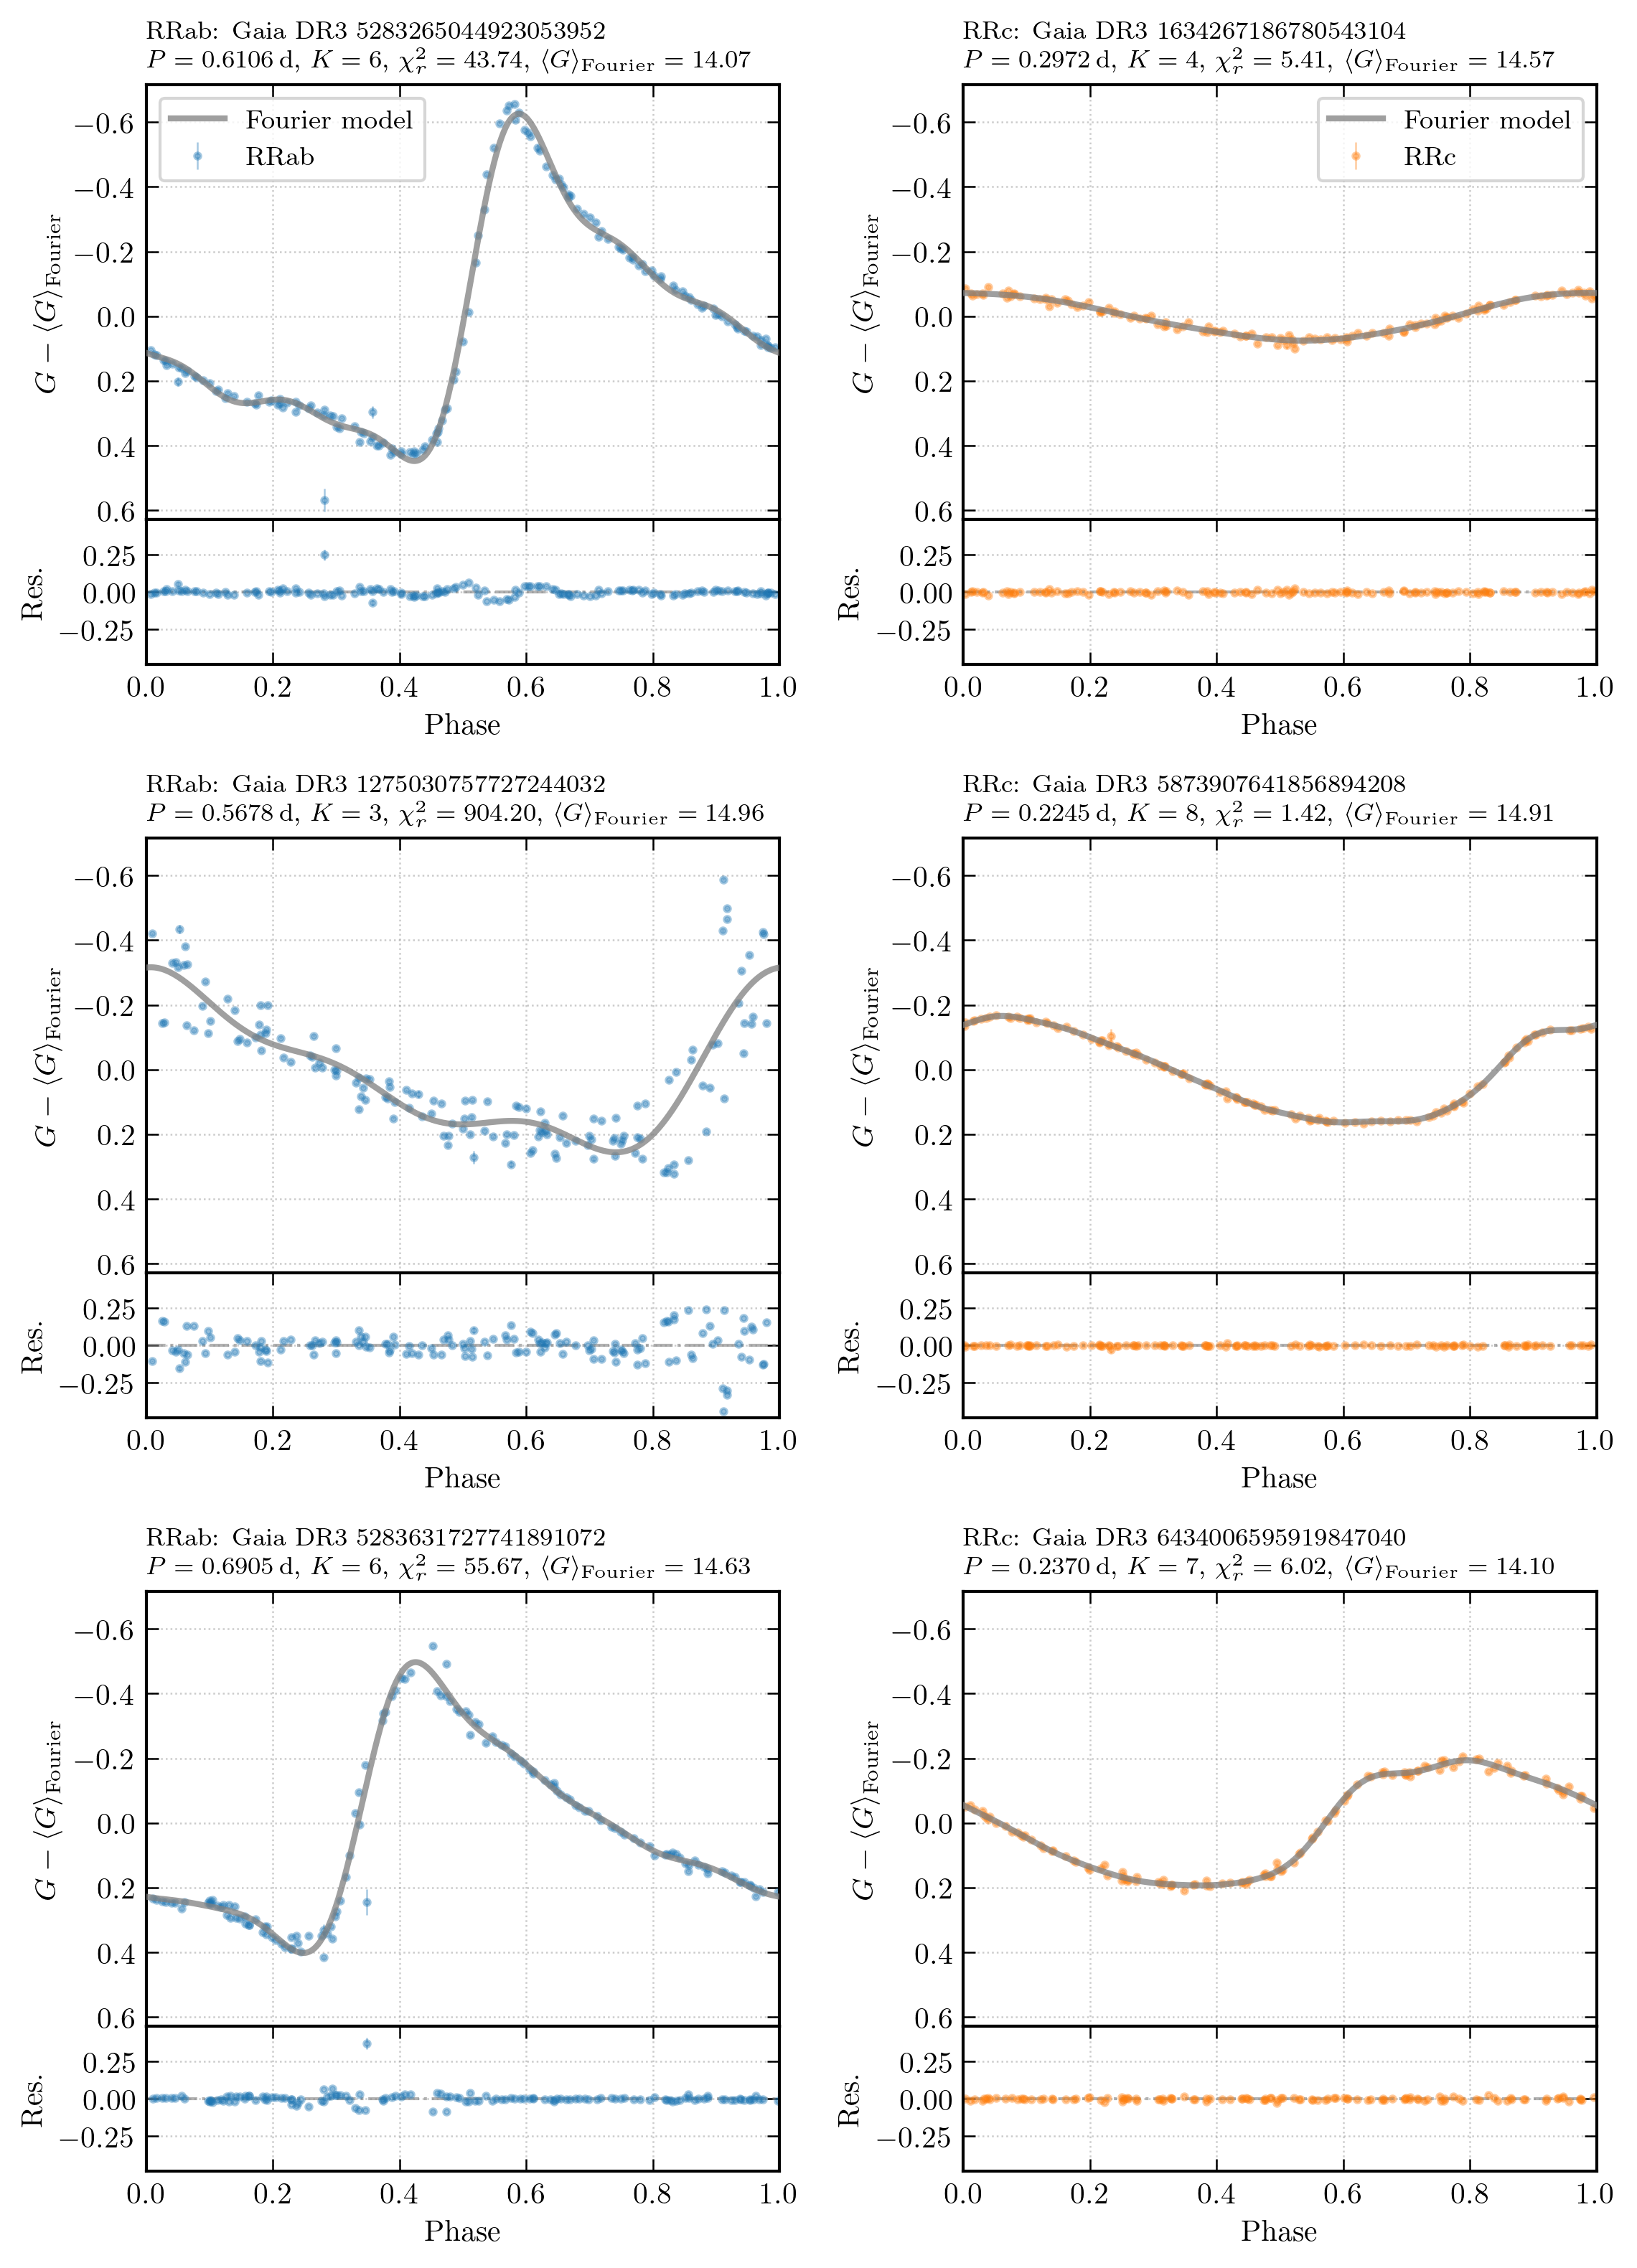

In [14]:
axes = plot_rrlyrae_shape_comparison(rrab, rrc)
plt.show()